# §4 General Trends — accelerator reporting across science

Establishes the phenomenon before any capacity or lifecycle estimates: how much
of science reports accelerator use, how *specifically* it reports it, in what
context, and how that differs by field.

**Denominator discipline.** Every share here is over the S2ORC full-text
population (`denominator.parquet`, one row per full-text paper), not over
accelerator papers — so "0 mentions" papers are in the base. Full-text coverage
by field-year is plotted first, because a change in corpus ingestion can
masquerade as a change in GPU adoption.

Inputs: `python -m accelscan.denominator` (denominator + paper_flags tables).

In [10]:
import os
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from accelscan.config import BUCKET, OUT_PREFIX
from accelscan.registry import load_registry
from accelscan.s3 import storage_options
from accelscan.plotting import install_year_tick_fix

install_year_tick_fix()   # no fractional year ticks (2007.5) on any figure

## Knobs

In [11]:
MODEL_TAG, PROMPT_VERSION = 'qwen3-14b', 'p1'
YEAR_MIN, YEAR_MAX = 2005, 2025
LOCAL_ANALYTIC = None      # e.g. 'output/analytic_smoke'
TOP_FIELDS = 8
MIN_PAPERS = 200           # suppress field-years with too little support

PAL = ['#0072B2', '#D55E00', '#009E73', '#CC79A7', '#E69F00', '#56B4E9',
       '#999999', '#000000']
reg = load_registry(); so = storage_options()

## Load analytic tables

In [12]:
base = (LOCAL_ANALYTIC or
        f's3://{BUCKET}/{OUT_PREFIX}/analytic/{reg.version}/{PROMPT_VERSION}/{MODEL_TAG}')
rd = (lambda name: pl.read_parquet(f'{base}/{name}.parquet')) if LOCAL_ANALYTIC else \
     (lambda name: pl.read_parquet(f'{base}/{name}.parquet', storage_options=so))

den = rd('denominator')
flags = rd('paper_flags')
papers = (den.join(flags, on='corpusid', how='left')
          .with_columns(
              accel_any=pl.col('accel_any').fill_null(False),
              accel_used=pl.col('accel_used').fill_null(False),
              model_specific=pl.col('model_specific').fill_null(False),
              model_specific_used=pl.col('model_specific_used').fill_null(False),
              is_candidate=pl.col('is_candidate').fill_null(False))
          .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX)))
print(f'{papers.height:,} full-text papers {YEAR_MIN}-{YEAR_MAX} | '
      f'{papers["accel_any"].sum():,} with an accelerator mention | '
      f'{papers["accel_used"].sum():,} reporting use')

11,790,600 full-text papers 2005-2025 | 339,601 with an accelerator mention | 258,312 reporting use


## 4.0 Corpus composition (read this before any trend)

Full-text papers per year and the share of the corpus each field contributes.
Discontinuities here propagate into every share below.

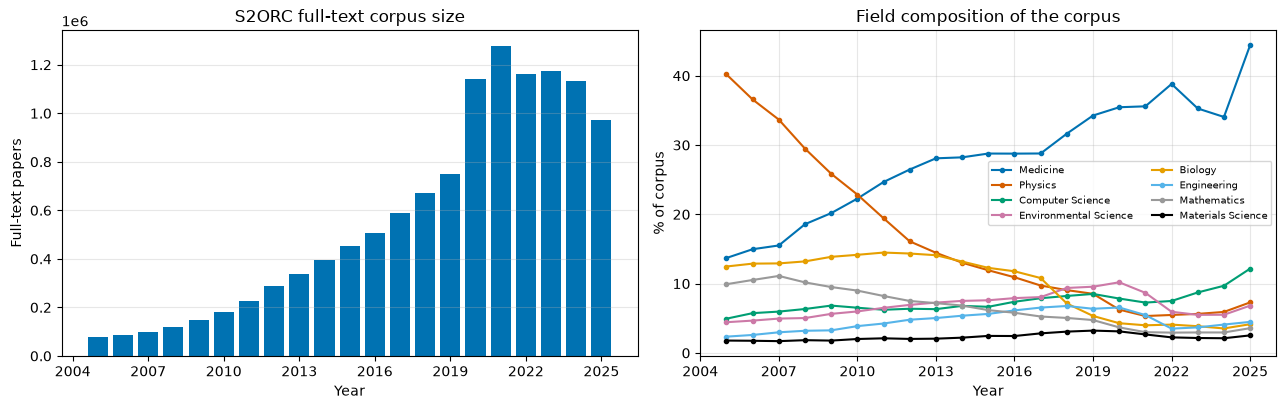

In [13]:
cy = papers.group_by('year').agg(papers=pl.len()).sort('year')
fields_top = (papers.filter(pl.col('field').is_not_null())
              .group_by('field').agg(n=pl.len()).sort('n', descending=True)
              .head(TOP_FIELDS)['field'].to_list())
fy = (papers.filter(pl.col('field').is_in(fields_top))
      .group_by('year', 'field').agg(n=pl.len()).sort('year'))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
axes[0].bar(cy['year'], cy['papers'], color='#0072B2')
axes[0].set(xlabel='Year', ylabel='Full-text papers', title='S2ORC full-text corpus size')
axes[0].grid(alpha=0.3, axis='y')
tot = dict(zip(cy['year'].to_list(), cy['papers'].to_list()))
for i, f in enumerate(fields_top):
    s = fy.filter(pl.col('field') == f)
    axes[1].plot(s['year'], [100 * n / tot[y] for y, n in zip(s['year'], s['n'])],
                 marker='.', label=f, color=PAL[i % len(PAL)])
axes[1].set(xlabel='Year', ylabel='% of corpus', title='Field composition of the corpus')
axes[1].legend(fontsize=7, ncol=2); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4.1 Prevalence of accelerator reporting

Three nested series: any mention, reported *use* (`used-in-this-work`), and
model-specific use. The gap between "any mention" and "use" is what the
usage-context classifier buys — papers that merely discuss GPUs are not counted
as using them.

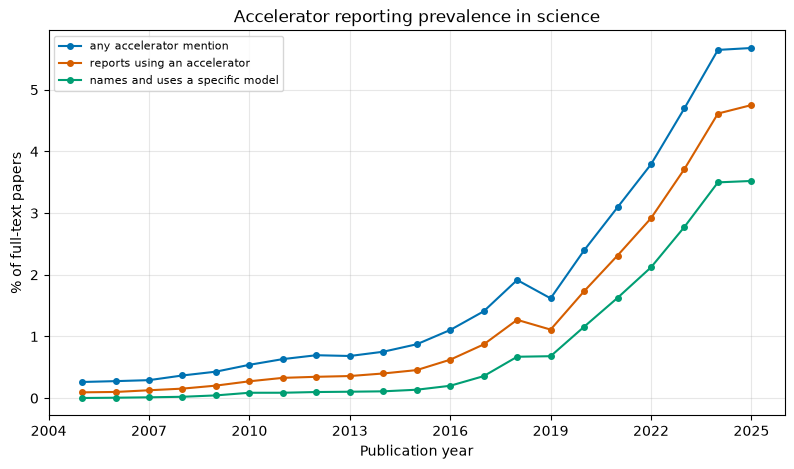

shape: (21, 6)
┌──────┬─────────┬───────────┬────────────┬─────────────────┬────────────┐
│ year ┆ n       ┆ any_share ┆ used_share ┆ modelspec_share ┆ cand_share │
│ ---  ┆ ---     ┆ ---       ┆ ---        ┆ ---             ┆ ---        │
│ i64  ┆ u32     ┆ f64       ┆ f64        ┆ f64             ┆ f64        │
╞══════╪═════════╪═══════════╪════════════╪═════════════════╪════════════╡
│ 2005 ┆ 76285   ┆ 0.0026    ┆ 0.0009     ┆ 0.0             ┆ 0.003434   │
│ 2006 ┆ 85514   ┆ 0.0028    ┆ 0.001      ┆ 0.0001          ┆ 0.00352    │
│ 2007 ┆ 100712  ┆ 0.0029    ┆ 0.0013     ┆ 0.0001          ┆ 0.003674   │
│ 2008 ┆ 120972  ┆ 0.0037    ┆ 0.0015     ┆ 0.0002          ┆ 0.004249   │
│ 2009 ┆ 147561  ┆ 0.0043    ┆ 0.002      ┆ 0.0004          ┆ 0.005028   │
│ 2010 ┆ 181767  ┆ 0.0054    ┆ 0.0027     ┆ 0.0009          ┆ 0.006167   │
│ 2011 ┆ 227579  ┆ 0.0063    ┆ 0.0033     ┆ 0.0009          ┆ 0.007013   │
│ 2012 ┆ 286761  ┆ 0.007     ┆ 0.0035     ┆ 0.001           ┆ 0.007686   │
│ 2013 ┆ 3

In [14]:
pv = (papers.group_by('year').agg(
        n=pl.len(),
        any_share=pl.col('accel_any').mean(),
        used_share=pl.col('accel_used').mean(),
        modelspec_share=pl.col('model_specific_used').mean(),
        cand_share=pl.col('is_candidate').mean())
      .filter(pl.col('n') >= MIN_PAPERS).sort('year'))
fig, ax = plt.subplots(figsize=(9.5, 5))
for lbl, col, c in [('any accelerator mention', 'any_share', '#0072B2'),
                    ('reports using an accelerator', 'used_share', '#D55E00'),
                    ('names and uses a specific model', 'modelspec_share', '#009E73')]:
    ax.plot(pv['year'], 100 * pv[col], marker='o', ms=4, label=lbl, color=c)
ax.set(xlabel='Publication year', ylabel='% of full-text papers',
       title='Accelerator reporting prevalence in science')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()
with pl.Config(tbl_rows=25):
    print(pv.with_columns(pl.col('any_share').round(4), pl.col('used_share').round(4),
                          pl.col('modelspec_share').round(4)))

## 4.2 Reporting specificity — do methods sections name the hardware?

Among papers that report *using* an accelerator, what share name a specific
model rather than only "a GPU"? This is a measurement-practice trend with a
direct policy hook: reproducibility/reporting standards for compute (an
analogue of CONSORT/PRISMA checklists). A flat or declining line means the
literature is getting *less* auditable even as compute grows.

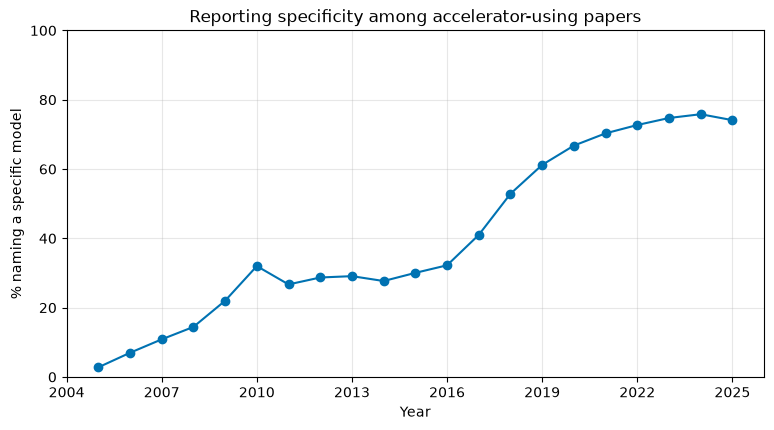

shape: (21, 3)
┌──────┬───────┬──────────┐
│ year ┆ n     ┆ specific │
│ ---  ┆ ---   ┆ ---      │
│ i64  ┆ u32   ┆ f64      │
╞══════╪═══════╪══════════╡
│ 2005 ┆ 72    ┆ 0.028    │
│ 2006 ┆ 86    ┆ 0.07     │
│ 2007 ┆ 129   ┆ 0.109    │
│ 2008 ┆ 187   ┆ 0.144    │
│ 2009 ┆ 300   ┆ 0.22     │
│ …    ┆ …     ┆ …        │
│ 2021 ┆ 29554 ┆ 0.703    │
│ 2022 ┆ 33932 ┆ 0.727    │
│ 2023 ┆ 43673 ┆ 0.747    │
│ 2024 ┆ 52243 ┆ 0.758    │
│ 2025 ┆ 46117 ┆ 0.741    │
└──────┴───────┴──────────┘


In [15]:
sp = (papers.filter(pl.col('accel_used'))
      .group_by('year').agg(n=pl.len(),
                            specific=pl.col('model_specific_used').mean())
      .filter(pl.col('n') >= 50).sort('year'))
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(sp['year'], 100 * sp['specific'], marker='o', color='#0072B2')
ax.set(xlabel='Year', ylabel='% naming a specific model', ylim=(0, 100),
       title='Reporting specificity among accelerator-using papers')
ax.grid(alpha=0.3); plt.show()
print(sp.with_columns(pl.col('specific').round(3)))

## 4.3 Mention-context mix

How accelerators appear when they appear: used here, discussed as prior work,
studied as the object of research, or speculative. Validates that the
usage-context labels behave sensibly over time and shows how much of the
literature would be miscounted by a naive "any mention = use" rule.

/tmp/ipykernel_789125/1385770335.py:4: DeprecationWarning: In Polars 2.0, the default behavior for `empty_as_null` will change to `False`. To keep the current behavior, explicitly set `empty_as_null=True`.
  .explode('usage_contexts').rename({'usage_contexts': 'ctx'})


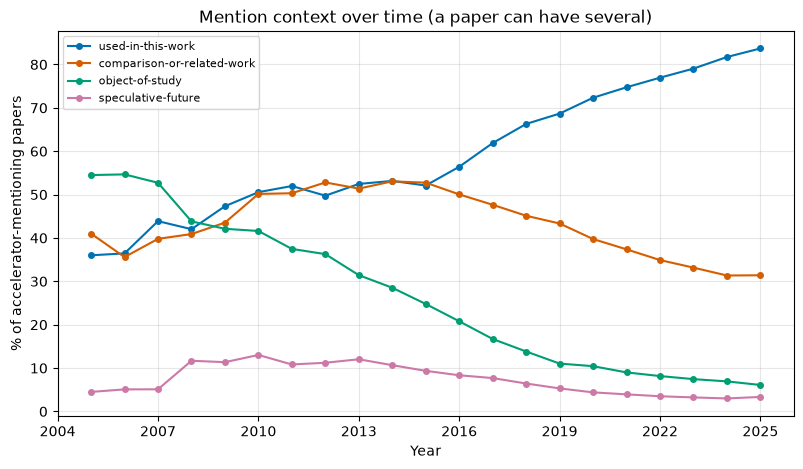

In [16]:
ctx = (flags.select('corpusid', 'usage_contexts')
       .join(den.select('corpusid', 'year'), on='corpusid', how='inner')
       .filter(pl.col('year').is_between(YEAR_MIN, YEAR_MAX))
       .explode('usage_contexts').rename({'usage_contexts': 'ctx'})
       .filter(pl.col('ctx').is_not_null()))
tot = ctx.group_by('year').agg(n=pl.col('corpusid').n_unique())
cs = (ctx.group_by('year', 'ctx').agg(k=pl.col('corpusid').n_unique())
      .join(tot, on='year').with_columns(share=pl.col('k') / pl.col('n'))
      .filter(pl.col('n') >= 100).sort('year'))
fig, ax = plt.subplots(figsize=(9.5, 5))
for i, c in enumerate(['used-in-this-work', 'comparison-or-related-work',
                       'object-of-study', 'speculative-future']):
    s = cs.filter(pl.col('ctx') == c)
    ax.plot(s['year'], 100 * s['share'], marker='o', ms=4, label=c, color=PAL[i])
ax.set(xlabel='Year', ylabel='% of accelerator-mentioning papers',
       title='Mention context over time (a paper can have several)')
ax.legend(fontsize=8); ax.grid(alpha=0.3); plt.show()

## 4.4 Field differences and adoption lag

Left: prevalence of reported accelerator use by field. Right: the year each
field first crossed 1% and 5% adoption, with lag behind the earliest field —
the diffusion-across-science measure.

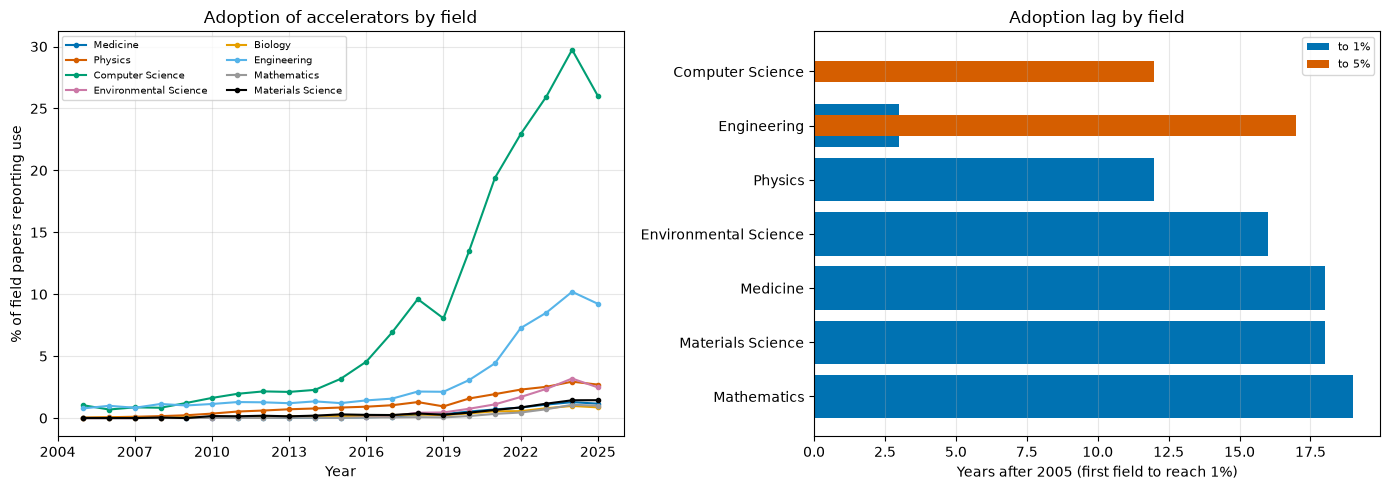

shape: (8, 3)
┌───────────────────────┬──────┬──────┐
│ field                 ┆ 1%   ┆ 5%   │
│ ---                   ┆ ---  ┆ ---  │
│ str                   ┆ i64  ┆ i64  │
╞═══════════════════════╪══════╪══════╡
│ Biology               ┆ null ┆ null │
│ Computer Science      ┆ 2005 ┆ 2017 │
│ Engineering           ┆ 2008 ┆ 2022 │
│ Physics               ┆ 2017 ┆ null │
│ Environmental Science ┆ 2021 ┆ null │
│ Medicine              ┆ 2023 ┆ null │
│ Materials Science     ┆ 2023 ┆ null │
│ Mathematics           ┆ 2024 ┆ null │
└───────────────────────┴──────┴──────┘


In [17]:
fd = (papers.filter(pl.col('field').is_in(fields_top))
      .group_by('field', 'year').agg(n=pl.len(), used=pl.col('accel_used').mean())
      .filter(pl.col('n') >= 100).sort('year'))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, f in enumerate(fields_top):
    s = fd.filter(pl.col('field') == f)
    if s.height > 2:
        axes[0].plot(s['year'], 100 * s['used'], marker='.', label=f, color=PAL[i % len(PAL)])
axes[0].set(xlabel='Year', ylabel='% of field papers reporting use',
            title='Adoption of accelerators by field')
axes[0].legend(fontsize=7, ncol=2); axes[0].grid(alpha=0.3)

rows = []
for f in fields_top:
    s = fd.filter(pl.col('field') == f).sort('year')
    for thr in (0.01, 0.05):
        hit = s.filter(pl.col('used') >= thr)
        rows.append({'field': f, 'threshold': f'{thr:.0%}',
                     'year': hit['year'][0] if hit.height else None})
lag = pl.DataFrame(rows)
one = lag.filter(pl.col('threshold') == '1%').drop_nulls().sort('year')
five = lag.filter(pl.col('threshold') == '5%').drop_nulls()
y0 = one['year'].min()
axes[1].barh(one['field'], [y - y0 for y in one['year']], color='#0072B2', label='to 1%')
fv = {r['field']: r['year'] for r in five.iter_rows(named=True)}
axes[1].barh([f for f in one['field'] if f in fv],
             [fv[f] - y0 for f in one['field'] if f in fv],
             height=0.4, color='#D55E00', label='to 5%')
axes[1].set(xlabel=f'Years after {y0} (first field to reach 1%)',
            title='Adoption lag by field')
axes[1].invert_yaxis(); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis='x')
plt.tight_layout(); plt.show()
print(lag.pivot(on='threshold', index='field', values='year').sort('1%'))

## 4.5 Candidate-filter funnel (measurement transparency)

From full-text papers to analyzed mentions. Publish this so readers can see
where the population narrows: filter → LLM → usage restriction.

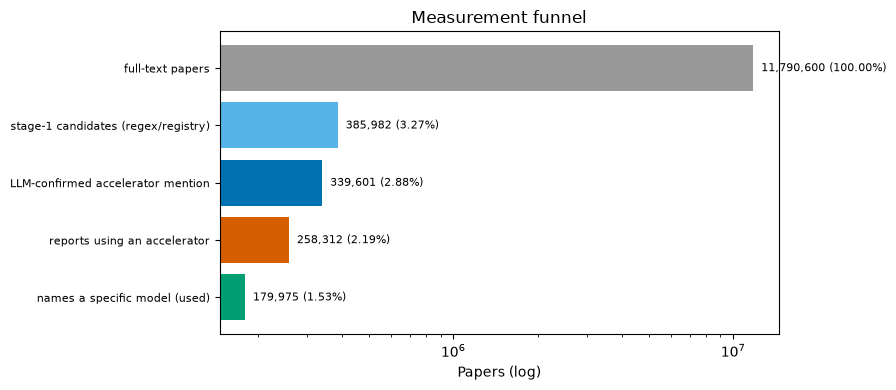

  11,790,600  100.00%  full-text papers
     385,982    3.27%  stage-1 candidates (regex/registry)
     339,601    2.88%  LLM-confirmed accelerator mention
     258,312    2.19%  reports using an accelerator
     179,975    1.53%  names a specific model (used)


In [18]:
funnel = {
    'full-text papers': papers.height,
    'stage-1 candidates (regex/registry)': int(papers['is_candidate'].sum()),
    'LLM-confirmed accelerator mention': int(papers['accel_any'].sum()),
    'reports using an accelerator': int(papers['accel_used'].sum()),
    'names a specific model (used)': int(papers['model_specific_used'].sum()),
}
fig, ax = plt.subplots(figsize=(9, 4))
labels, vals = list(funnel), list(funnel.values())
ax.barh(range(len(vals)), vals, color=['#999999', '#56B4E9', '#0072B2', '#D55E00', '#009E73'])
ax.set_yticks(range(len(vals))); ax.set_yticklabels(labels, fontsize=8)
ax.set_xscale('log'); ax.invert_yaxis()
for i, v in enumerate(vals):
    ax.text(v, i, f'  {v:,} ({100*v/vals[0]:.2f}%)', va='center', fontsize=8)
ax.set(xlabel='Papers (log)', title='Measurement funnel')
plt.tight_layout(); plt.show()
for k, v in funnel.items():
    print(f'{v:12,}  {100*v/vals[0]:6.2f}%  {k}')